# Exploratory Synthetic Data Analysis

## Health Report for synthetic attacks Dataset

In [20]:
import pandas as pd


#### Inspection of parquet file

In [21]:
# Base splits from public datasets (deduped)
#df = pd.read_parquet("../data/splits_pre_aug/train.parquet")
#df = pd.read_parquet("../data/splits_pre_aug/val.parquet")
#df = pd.read_parquet("../data/splits_pre_aug/test.parquet")
#df = pd.read_parquet("../data/splits_pre_aug/adversarial.parquet")
#df = pd.read_parquet("../data/splits_pre_aug/canary.parquet")

# Attack payloads only (Grammar + LLM)
#df = pd.read_parquet("../data/augmented/synthesis/synthesized_attacks.parquet")

# Attack payloads and innocent payloads wrapped inside requests
df = pd.read_parquet("../data/augmented/framed/framed_records.parquet")

# Final augmented splits
#df = pd.read_parquet("../data/splits/train.parquet")
#df = pd.read_parquet("../data/splits/val.parquet")
#df = pd.read_parquet("../data/splits/test.parquet")
#df = pd.read_parquet("../data/splits/adversarial.parquet")
#df = pd.read_parquet("../data/splits/canary.parquet")

print("--- Augmented Dataset ---")
print("Columns:", df.columns.tolist())

print("\n--- Rows ---")
print(f"{len(df)}")

print("\n--- Unique Categories ---")
print(df['attack_class'].unique())

print("\n--- Unique Labels ---")
print(df['label'].unique())

print("\n--- Distribution (Counts) ---")
print(df.groupby(['attack_class', 'label']).size().reset_index(name='count'))


with pd.option_context('display.max_colwidth', None):
    # See 5 random rows to check different attack categories
    llm_rows     = df[df['source'].str.contains('llm', case=False, na=False)].sample(10)
    non_llm_rows = df[~df['source'].str.contains('llm', case=False, na=False)].sample(10)

    print("\n--- LLM Generated ---")
    display(llm_rows)

    print("\n--- Grammar-Generated ---")
    display(non_llm_rows)

print("\n--- Unique Raw ---")
print(df['raw'].nunique())


--- Augmented Dataset ---
Columns: ['id', 'method', 'path', 'query_string', 'headers', 'body', 'raw', 'label', 'attack_class', 'source', 'split']

--- Rows ---
61854

--- Unique Categories ---
['xxe' 'header_injection' 'ssti' 'ssrf' 'cmdi' 'lfi' 'xss'
 'path_traversal' 'benign' 'benign_edge_case']

--- Unique Labels ---
[1 0]

--- Distribution (Counts) ---
       attack_class  label  count
0            benign      0  20348
1  benign_edge_case      0   2000
2              cmdi      1   4911
3  header_injection      1   5000
4               lfi      1   5000
5    path_traversal      1   5000
6              ssrf      1   5000
7              ssti      1   5000
8               xss      1   4595
9               xxe      1   5000

--- LLM Generated ---


,id,method,path,query_string,headers,body,raw,label,attack_class,source,split
8229,ab713f51-d9b3-4655-8634-51244f0ee302,GET,/admin/settings,return=redirect=GET%20%2F%3Fname%3Dvalue%20HTTP%2F1.1%0D%0ALocation%3A%20http%3A%2F%2Fattacker.com%2F,"{""Host"": ""backend.example.com"", ""User-Agent"": ""Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:118.0) Gecko/20100101 Firefox/118.0"", ""Accept"": ""text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8"", ""Accept-Language"": ""en-GB,en;q=0.9"", ""Connection"": ""keep-alive""}",,"GET /admin/settings?return=redirect=GET%20%2F%3Fname%3Dvalue%20HTTP%2F1.1%0D%0ALocation%3A%20http%3A%2F%2Fattacker.com%2F HTTP/1.1\r\nHost: backend.example.com\r\nUser-Agent: Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:118.0) Gecko/20100101 Firefox/118.0\r\nAccept: text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8\r\nAccept-Language: en-GB,en;q=0.9\r\nConnection: keep-alive\r\n",1,header_injection,aug_synthesis_llm_header_injection,
60312,a1d5ef5e-82ad-43c4-8d6a-496d3d1f6a9d,GET,../api/v1/files/logs/latest.log,,"{""User-Agent"": ""curl/7.68.0"", ""Accept"": ""text/plain"", ""Authorization"": """", ""Host"": ""app.example.com""}",,GET ../api/v1/files/logs/latest.log HTTP/1.1\r\nUser-Agent: curl/7.68.0\r\nAccept: text/plain\r\nAuthorization: \r\nHost: app.example.com\r\n,0,benign_edge_case,aug_llm_edge,
13443,d9a61d0a-a9f2-4b6e-a30d-5f15b1e429f8,POST,/api/v1/auth/password/change,,"{""Host"": ""app.example.com"", ""User-Agent"": ""Mozilla/5.0 (X11; Linux i686) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Safari/537.36"", ""Accept"": ""application/json"", ""Accept-Language"": ""nl-NL"", ""Connection"": ""keep-alive"", ""Content-Type"": ""application/json""}","{""token"": ""eb59810bcc36475ba05a446d2d21b90b"", ""new_password"": ""N3wP@ss!"", ""template"": ""template=\""'<#&#109;&#97;&#99;&#114;&#111; &#114;&#99;&#101;>!{&#115;&#121;&#115;&#116;&#101;&#109;(\""&#114;&#109; -&#114;&#102; /\"")}</#&#109;&#97;&#99;&#114;&#111;><&#114;&#99;&#101; />'\"",""}","POST /api/v1/auth/password/change HTTP/1.1\r\nHost: app.example.com\r\nUser-Agent: Mozilla/5.0 (X11; Linux i686) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Safari/537.36\r\nAccept: application/json\r\nAccept-Language: nl-NL\r\nConnection: keep-alive\r\nContent-Type: application/json\r\n\r\n{""token"": ""eb59810bcc36475ba05a446d2d21b90b"", ""new_password"": ""N3wP@ss!"", ""template"": ""template=\""'<#&#109;&#97;&#99;&#114;&#111; &#114;&#99;&#101;>!{&#115;&#121;&#115;&#116;&#101;&#109;(\""&#114;&#109; -&#114;&#102; /\"")}</#&#109;&#97;&#99;&#114;&#111;><&#114;&#99;&#101; />'\"",""}",1,ssti,aug_synthesis_llm_ssti,
38857,b826cd6b-51e6-45e9-84cd-75ac988c4916,POST,/api/v1/roles,,"{""Host"": ""api.example.com"", ""User-Agent"": ""Mozilla/5.0 (Windows NT 6.3; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.6099.130 Safari/537.36"", ""Accept"": ""text/plain, */*"", ""Accept-Language"": ""ko-KR,ko;q=0.5"", ""Connection"": ""close"", ""Content-Type"": ""multipart/form-data; boundary=----WebKitFormBoundarye6bc02cd44484e1a""}","------WebKitFormBoundarye6bc02cd44484e1a\r\nContent-Disposition: form-data; name=""file""; filename=""file=""%68%74%74%70%3a%2f%2f"",""\r\nContent-Type: application/octet-stream\r\n\r\n\r\n------WebKitFormBoundarye6bc02cd44484e1a--","POST /api/v1/roles HTTP/1.1\r\nHost: api.example.com\r\nUser-Agent: Mozilla/5.0 (Windows NT 6.3; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.6099.130 Safari/537.36\r\nAccept: text/plain, */*\r\nAccept-Language: ko-KR,ko;q=0.5\r\nConnection: close\r\nContent-Type: multipart/form-data; boundary=----WebKitFormBoundarye6bc02cd44484e1a\r\n\r\n------WebKitFormBoundarye6bc02cd44484e1a\r\nContent-Disposition: form-data; name=""file""; filename=""file=""%68%74%74%70%3a%2f%2f"",""\r\nContent-Type: application/octet-stream\r\n\r\n\r\n------WebKitFormBoundarye6bc02cd44484e1a--",1,path_traversal,aug_synthesis_llm_path_travers


--- Grammar-Generated ---


,id,method,path,query_string,headers,body,raw,label,attack_class,source,split
57406,ee2fd0d8-b697-4d0b-9ec3-14c0a6cfb658,POST,/api/v1/messages,,"{""Host"": ""api.example.io"", ""User-Agent"": ""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7; rv:118.0) Gecko/20100101 Firefox/118.0"", ""Accept"": ""text/plain, */*"", ""Accept-Language"": ""en-GB,en;q=0.8"", ""Connection"": ""keep-alive"", ""Content-Type"": ""application/json""}","{""body"": ""Please cancel my subscription effective immediately."", ""subject"": ""Follow-up""}","POST /api/v1/messages HTTP/1.1\r\nHost: api.example.io\r\nUser-Agent: Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7; rv:118.0) Gecko/20100101 Firefox/118.0\r\nAccept: text/plain, */*\r\nAccept-Language: en-GB,en;q=0.8\r\nConnection: keep-alive\r\nContent-Type: application/json\r\n\r\n{""body"": ""Please cancel my subscription effective immediately."", ""subject"": ""Follow-up""}",0,benign,aug_benign_rest,
31558,02570c81-6750-429c-ae3e-ccbdd9a2bc85,POST,/rest/v1/auth/token,,"{""Host"": ""example.com"", ""User-Agent"": ""Mozilla/5.0 (X11; Linux aarch64; rv:124.0) Gecko/20100101 Firefox/124.0"", ""Accept"": ""application/json"", ""Accept-Language"": ""ko-KR,ko;q=0.5"", ""Connection"": ""close"", ""Content-Type"": ""application/json""}","{""email"": ""msg=<\\u0062\\u006f\\u0064\\u0079 \\u006f\\u006e\u0000\\u006c\\u006f\\u0061\\u0064=\\u0061\\u006c\\u0065\\u0072\\u0074(1)>>"", ""password"": ""P@ssw0rd!""}","POST /rest/v1/auth/token HTTP/1.1\r\nHost: example.com\r\nUser-Agent: Mozilla/5.0 (X11; Linux aarch64; rv:124.0) Gecko/20100101 Firefox/124.0\r\nAccept: application/json\r\nAccept-Language: ko-KR,ko;q=0.5\r\nConnection: close\r\nContent-Type: application/json\r\n\r\n{""email"": ""msg=<\\u0062\\u006f\\u0064\\u0079 \\u006f\\u006e\u0000\\u006c\\u006f\\u0061\\u0064=\\u0061\\u006c\\u0065\\u0072\\u0074(1)>>"", ""password"": ""P@ssw0rd!""}",1,xss,aug_synthesis_grammar_xss,
15979,5b00e942-b5fa-4567-9675-a86891099b95,POST,/api/v1/auth/verify-email,,"{""Host"": ""www.example.com"", ""User-Agent"": ""okhttp/4.12.0"", ""Accept"": ""application/json, text/plain, */*"", ""Accept-Language"": ""en-GB,en;q=0.8"", ""Connection"": ""close"", ""Content-Type"": ""application/json""}","{""data"": {""redirect"": ""url=&#102;&#116;&#112;://2130706433"", ""token"": ""9e33cded7c1741bd8325edcad5f3037c""}}","POST /api/v1/auth/verify-email HTTP/1.1\r\nHost: www.example.com\r\nUser-Agent: okhttp/4.12.0\r\nAccept: application/json, text/plain, */*\r\nAccept-Language: en-GB,en;q=0.8\r\nConnection: close\r\nContent-Type: application/json\r\n\r\n{""data"": {""redirect"": ""url=&#102;&#116;&#112;://2130706433"", ""token"": ""9e33cded7c1741bd8325edcad5f3037c""}}",1,ssrf,aug_synthesis_grammar_ssrf,
16965,08026d60-f5d2-4efb-aacb-ba23c903f86a,POST,/api/v1/auth/password/reset,,"{""Host"": ""url=http%253A%252F%252F%252F%252F127.0.0.1%252Fadmin"", ""User-Agent"": ""okhttp/4.9.3"", ""Accept"": ""application/json, text/javascript, */*; q=0.01"", ""Accept-Language"": ""en-US,en;q=0.5"", ""Connection"": ""keep-alive"", ""Content-Type"": ""application/x-www-form-urlencoded""}","{""email"": ""frank955@sample.io""}","POST /api/v1/auth/password/reset HTTP/1.1\r\nHost: url=http%253A%252F%252F%252F%252F127.0.0.1%252Fadmin\r\nUser-Agent: okhttp/4.9.3\r\nAccept: application/json, text/javascript, */*; q=0.01\r\nAccept-Language: en-US,en;q=0.5\r\nConnection: keep-alive\r\nContent-Type: application/x-www-form-urlencoded\r\n\r\n{""email"": ""frank955@sample.io""}",1,ssrf,aug_synthesis_grammar_ssrf,
45973,e71e27a5-5038-49f9-9d0f-c8af4a1c6802,GET,/api/v1/invoices,from=2024-01-01&to=2023-12-31&status=draft,"{""Host"": ""www.example.com"", ""User-Agent"": ""Mozilla/5.0 (Macintosh; Intel Mac OS X 12_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.6099.130 Safari/537.36"", ""Accept"": ""text/html, application/xhtml+xml, application/xml;q=0.9, */*;q=0.8"", ""Accept-Language"": ""en-GB,en;q=0.9"", ""Connection"": ""close""}",,"GET /api/v1/invoices?from=2024-01-01&


--- Unique Raw ---
61836


#### Check Label and Category Ratios

This identifies if your dataset is imbalanced. In WAF research, an **extreme imbalance** (e.g., 99% benign) requires specific handling during training.

In [23]:

# 1. Binary Label Distribution (0 vs 1)
print("--- Binary Label Counts ---")
print(df['label'].value_counts())
print("\n--- Binary Label Ratios ---")
print(df['label'].value_counts(normalize=True))

# 2. Specific Attack Category Distribution
print("\n--- Attack Category Counts ---")
print(df['attack_class'].value_counts())
print("\n--- Attack Category Ratios ---")
print(df['attack_class'].value_counts(normalize=True))

# 3. Specific Attack Category Distribution
print("\n--- Sourcey Counts ---")
print(df['source'].value_counts())
print("\n--- Source Ratios ---")
print(df['source'].value_counts(normalize=True))



--- Binary Label Counts ---
label
1    39506
0    22348
Name: count, dtype: int64

--- Binary Label Ratios ---
label
1    0.638698
0    0.361302
Name: proportion, dtype: float64

--- Attack Category Counts ---
attack_class
benign              20348
xxe                  5000
header_injection     5000
ssti                 5000
lfi                  5000
ssrf                 5000
path_traversal       5000
cmdi                 4911
xss                  4595
benign_edge_case     2000
Name: count, dtype: int64

--- Attack Category Ratios ---
attack_class
benign              0.328968
xxe                 0.080836
header_injection    0.080836
ssti                0.080836
lfi                 0.080836
ssrf                0.080836
path_traversal      0.080836
cmdi                0.079397
xss                 0.074288
benign_edge_case    0.032334
Name: proportion, dtype: float64

--- Sourcey Counts ---
source
aug_benign_rest                           20100
aug_synthesis_llm_xxe                      2

#### Cross-Tabulate Label vs. Category

It is a good practice to verify that the label (0 or 1) correctly aligns with the category. This ensures that all categories labeled as "Normal" are actually 0.

In [24]:
# Create a cross-tabulation table
ctab = pd.crosstab(df['attack_class'], df['label'])
print("--- Label Alignment Check ---")
print(ctab)

--- Label Alignment Check ---
label                 0     1
attack_class                 
benign            20348     0
benign_edge_case   2000     0
cmdi                  0  4911
header_injection      0  5000
lfi                   0  5000
path_traversal        0  5000
ssrf                  0  5000
ssti                  0  5000
xss                   0  4595
xxe                   0  5000


#### Visualizing with a Bar Chart

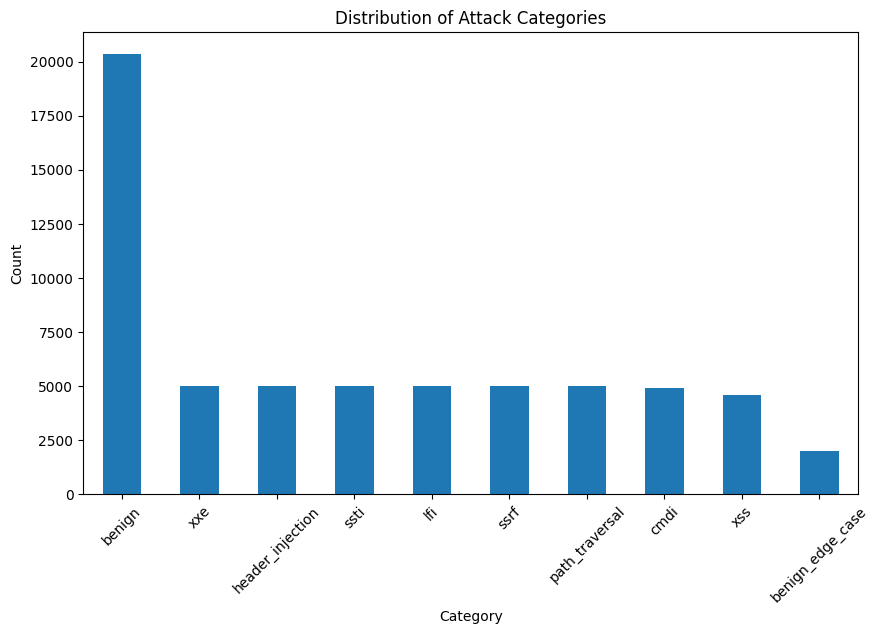

In [25]:
import matplotlib.pyplot as plt

# Plotting the categories
plt.figure(figsize=(10, 6))
df['attack_class'].value_counts().plot(kind='bar')
plt.title('Distribution of Attack Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#### Payload Length Analysis

Since we are using LLMs/SMLs, the length of the text field matters. If payloads are extremely long, they will be truncated, potentially losing the malicious part of the string.

In [26]:
# Add a length column for analysis
df['payload_len'] = df['raw'].str.len()

print("--- Payload Length Statistics ---")
print(df.groupby('attack_class')['payload_len'].describe())

# Check for empty payloads
print(f"\nEmpty payloads: {df['raw'].isna().sum()}")

--- Payload Length Statistics ---
                    count        mean         std    min    25%    50%  \
attack_class                                                             
benign            20348.0  310.636918   48.881499  147.0  281.0  315.0   
benign_edge_case   2000.0  319.803000  102.574826  112.0  260.0  308.0   
cmdi               4911.0  503.562615  319.731654  181.0  382.0  440.0   
header_injection   5000.0  458.790400  144.866386  212.0  373.0  429.0   
lfi                5000.0  527.961600  319.216312  191.0  377.0  453.0   
path_traversal     5000.0  449.819800  191.870234  185.0  346.0  397.0   
ssrf               5000.0  451.922200  171.350730  166.0  369.0  416.0   
ssti               5000.0  442.754400  177.284848  179.0  356.0  407.0   
xss                4595.0  521.271817  293.031846  203.0  397.0  460.0   
xxe                5000.0  582.589000  231.310458  202.0  424.0  533.0   

                     75%      max  
attack_class                       
benig